# Avance 2 – Ingeniería de Características

## Contexto del proyecto

El objetivo del proyecto es construir un modelo de aprendizaje automático que estime el gasto mensual de viajes por **unidad de primer nivel × partida presupuestal**, para las 8 partidas vigiladas por FIRA. La unidad de observación del modelo final es **centro gestor × partida × mes**; en este avance operamos al nivel granular de concepto de gasto.

Las decisiones de este avance siguen la fase de **Preparación de Datos** de la metodología **CRISP-ML(Q)**, que exige justificar cada transformación en función del problema de negocio y de los hallazgos del EDA (Avance 1).

---
## 0. Imports y configuración

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import boxcox
from sklearn.feature_selection import VarianceThreshold, f_regression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.4f}'.format)

PALETTE = ['#1a5276', '#2980b9', '#85c1e9', '#e74c3c', '#e67e22',
           '#2ecc71', '#8e44ad', '#f39c12', '#1abc9c', '#c0392b',
           '#16a085', '#d35400']
sns.set_style('whitegrid')
sns.set_palette(PALETTE)

PARTIDAS_MODELO = [26102, 26104, 37101, 37104, 37201, 37204, 37501, 37504]
TARIFAS = {
    (1, 'Zona A', 'FUNCIONARIO')       : (2290, 647, 230),
    (1, 'Zona B', 'FUNCIONARIO')       : (1810, 600, 230),
    (1, 'Zona A', 'RESTO DE PERSONAL') : (1510, 600, 170),
    (1, 'Zona B', 'RESTO DE PERSONAL') : (1290, 600, 170),
    (2, 'Zona A', 'FUNCIONARIO')       : (2290, 647, 230),
    (2, 'Zona B', 'FUNCIONARIO')       : (1810, 600, 230),
    (2, 'Zona A', 'RESTO DE PERSONAL') : (1510, 600, 170),
    (2, 'Zona B', 'RESTO DE PERSONAL') : (1290, 600, 170),
    (3, 'Zona A', 'FUNCIONARIO')       : (2704, 647, 260),
    (3, 'Zona A', 'RESTO DE PERSONAL') : (1635, 620, 230),
}

print('Librerías cargadas.')

Librerías cargadas.


---
## 1. Carga del dataset y filtro de partidas

In [19]:
DATA_PATH = 'historico_SAP_2.parquet'
df_raw = pd.read_parquet(DATA_PATH)
print(f'Dataset crudo: {len(df_raw):,} registros, {df_raw.shape[1]} columnas')

# Se conservan únicamente las 8 partidas del modelo (excluye 32502 – Renta de Vehículo)
df = df_raw[df_raw['Partida Presupuestal'].isin(PARTIDAS_MODELO)].copy()
print(f'Dataset de trabajo: {len(df):,} registros')
df.head(3)

Dataset crudo: 506,149 registros, 17 columnas
Dataset de trabajo: 506,039 registros


,Clave Empleado,Viaje,Clave Concepto,Concepto,Fecha Contable,Cuenta Contable,Partida Presupuestal,Funcionario o resto de personal,Grupo Tipo Viaje,Clave Centro Costo,Fecha inicio,Fecha Final,Documento Contable,Monto Gasto,Destino,Periodo,Zona
0,"9,146.0000","3,924.0000",132,Cuota sin comprobar,2019-08-02,5302937504,37504,FUNCIONARIO,GC,10000000,2019-07-22,2019-07-23,1280021356,232.0000,"MORELIA, MCH",1,Zona B
1,"9,146.0000","3,924.0000",131,Alimentación-Hospedaje,2019-08-02,5302937504,37504,FUNCIONARIO,GC,10000000,2019-07-22,2019-07-23,1280021356,"1,814.5400","MORELIA, MCH",1,Zona B
2,"9,146.0000","3,924.0000",129,Impuestos Alim-Hosp,2019-08-02,5302937504,37504,FUNCIONARIO,GC,10000000,2019-07-22,2019-07-23,1280021356,344.7700,"MORELIA, MCH",1,Zona B


---
## A. Construcción de nuevas características

La construcción de características convierte la información latente en los datos crudos en variables explícitas que el modelo puede aprovechar.  
Cada decisión se justifica desde la perspectiva del negocio y los hallazgos del EDA.

### A.1 Variables temporales derivadas de la Fecha Contable

In [20]:
df['anio']     = df['Fecha Contable'].dt.year
df['mes']      = df['Fecha Contable'].dt.month
df['trimestre'] = df['Fecha Contable'].dt.quarter
df['anio_mes'] = df['Fecha Contable'].dt.to_period('M')

print('Distribución por año:')
print(df['anio'].value_counts().sort_index())

Distribución por año:
anio
2018    107781
2019    105208
2020     27788
2021     32424
2022     33732
2023     56795
2024     58952
2025     61012
2026     22347
Name: count, dtype: int64


**Justificación:**  
El EDA (sección 5.3) identificó una estacionalidad mensual clara: valle en agosto, pico en noviembre. La variable `mes` captura ese patrón. El `trimestre` es una versión más granular que el año pero más estable que el mes individual, útil como alternativa. El `anio` distingue el efecto de la pandemia (2020-2021) y la tendencia inflacionaria. Estas tres variables, junto con `Periodo`, evitan que el modelo interprete el tiempo como una sola dimensión lineal.

### A.2 Duración del viaje y desfase contable

In [21]:
df['duracion_dias'] = (df['Fecha Final'] - df['Fecha inicio']).dt.days + 1
df['desfase_dias']  = (df['Fecha Contable'] - df['Fecha inicio']).dt.days

print('Duración del viaje (días):')
print(df['duracion_dias'].describe().to_frame().T.round(2))
print(f'\nRegistros sin Fecha inicio (sin duracion_dias): {df["duracion_dias"].isna().sum():,}')

print('\nDesfase contable (días entre inicio de viaje y registro):')
print(df['desfase_dias'].describe().to_frame().T.round(2))

Duración del viaje (días):
                     count   mean    std    min    25%    50%    75%     max
duracion_dias 505,998.0000 1.6200 1.4100 1.0000 1.0000 1.0000 2.0000 23.0000

Registros sin Fecha inicio (sin duracion_dias): 41

Desfase contable (días entre inicio de viaje y registro):
                    count    mean     std       min    25%    50%     75%  \
desfase_dias 505,998.0000 11.2500 10.9200 -340.0000 6.0000 9.0000 14.0000   

                    max  
desfase_dias 1,454.0000  


**Justificación – `duracion_dias`:**  
Es el predictor con mayor correlación de Pearson con `Monto Gasto` (r = 0.45, F = 130,784 en el test de F-regresión). A más días de viaje, mayor gasto acumulado. Para las partidas de viáticos (375xx) la duración determina directamente el tope tarifario máximo.

**Justificación – `desfase_dias`:**  
El EDA mostró que la mediana del desfase es 7–14 días. Un desfase alto puede indicar comprobaciones tardías o viajes con múltiples conceptos. Correlación con Monto Gasto: r = 0.20, F = 21,916. Se mantiene como señal de complejidad del viaje.

### A.3 Características agregadas por viaje (empleado × viaje)

Correlación con Monto Gasto:
  gasto_acum_viaje  : 0.5472
  n_conceptos_viaje : 0.2030


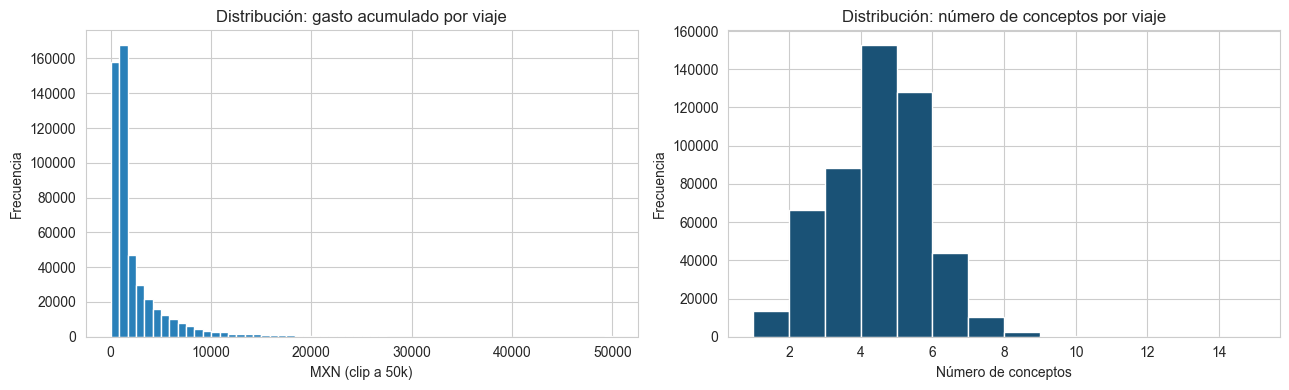

In [22]:
# Gasto total acumulado del mismo empleado-viaje (contexto del monto individual)
df['gasto_acum_viaje'] = (df.groupby(['Clave Empleado', 'Viaje'])['Monto Gasto']
                            .transform('sum'))

# Número de conceptos distintos dentro del mismo viaje (proxy de complejidad)
df['n_conceptos_viaje'] = (df.groupby(['Clave Empleado', 'Viaje'])['Concepto']
                             .transform('nunique'))

print('Correlación con Monto Gasto:')
print(f'  gasto_acum_viaje  : {df[["gasto_acum_viaje","Monto Gasto"]].dropna().corr().iloc[0,1]:.4f}')
print(f'  n_conceptos_viaje : {df[["n_conceptos_viaje","Monto Gasto"]].dropna().corr().iloc[0,1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['gasto_acum_viaje'].clip(0, 50000), bins=60, color='#2980b9', edgecolor='white')
axes[0].set_title('Distribución: gasto acumulado por viaje')
axes[0].set_xlabel('MXN (clip a 50k)')
axes[0].set_ylabel('Frecuencia')
axes[1].hist(df['n_conceptos_viaje'], bins=range(1,16), color='#1a5276', edgecolor='white')
axes[1].set_title('Distribución: número de conceptos por viaje')
axes[1].set_xlabel('Número de conceptos')
axes[1].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

**Justificación:**  
`gasto_acum_viaje` es la variable construida con mayor correlación con el monto individual (r = 0.55). Pone en contexto si el concepto específico corresponde a un viaje de alto o bajo costo global. `n_conceptos_viaje` captura la complejidad del viaje: un viaje con 6 conceptos (hostal + avión + taxis + gasolina + cuota + impuesto) es inherentemente diferente de uno con 1. Ambas son **features de nivel viaje** que enriquecen el análisis de nivel concepto.

### A.4 Fracción del tope tarifario ejercida (partidas 37501 y 37504)

Estadísticas de fracción del tope:
                     count   mean    std     min    25%    50%    75%    max
fraccion_tope 242,980.0000 0.2963 0.2255 -1.2141 0.1377 0.2208 0.4568 2.9682

Registros que exceden el tope: 1,148 (0.47%)


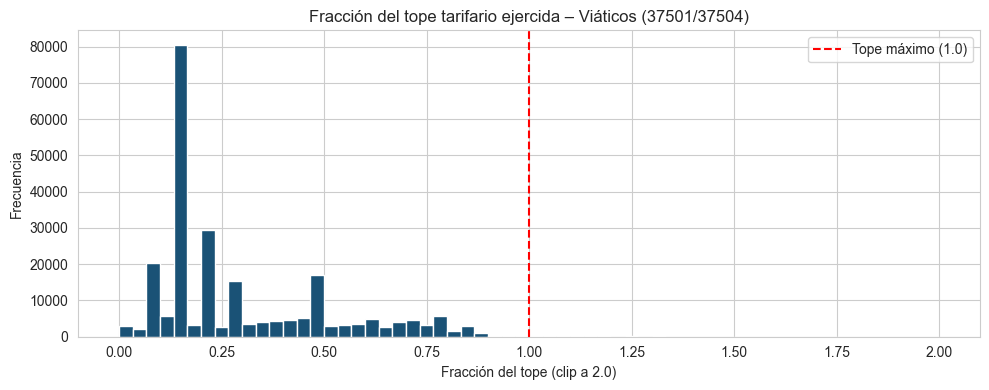

In [23]:
CONC_ALIM  = ['Alimentación-Hospedaje', 'Alimentación sin Pernocta']
CONC_CUOTA = ['Cuota sin comprobar']

def calcular_tope_total(row):
    """
    Calcula el tope máximo de viáticos (alimentos + cuota sin comprobar)
    para un registro dado, según las tarifas históricas FIRA.
    """
    key = (int(row['Periodo']), row['Zona'], row['Funcionario o resto de personal'])
    if key not in TARIFAS:
        return np.nan
    hosp_alim, alim_sin_pernocta, cuota = TARIFAS[key]
    dias = max(1, int(row['dias_viaje']))
    tope_alim = alim_sin_pernocta if dias == 1 else (dias - 1) * hosp_alim + alim_sin_pernocta
    tope_cuota = dias * cuota
    return tope_alim + tope_cuota

mask_viat = (
    df['Partida Presupuestal'].isin([37501, 37504]) &
    df['Concepto'].isin(CONC_ALIM + CONC_CUOTA) &
    df['Fecha inicio'].notna()
)
df_viat = df[mask_viat].copy()
df_viat['dias_viaje'] = df_viat['duracion_dias'].fillna(1)
df_viat['tope_total'] = df_viat.apply(calcular_tope_total, axis=1)
df_viat['fraccion_tope'] = df_viat['Monto Gasto'] / df_viat['tope_total']

print('Estadísticas de fracción del tope:')
print(df_viat['fraccion_tope'].describe().to_frame().T.round(4))
excede = (df_viat['fraccion_tope'] > 1.0).sum()
print(f'\nRegistros que exceden el tope: {excede:,} ({excede/len(df_viat)*100:.2f}%)')

fig, ax = plt.subplots(figsize=(10, 4))
df_viat['fraccion_tope'].clip(0, 2).hist(bins=60, color='#1a5276', edgecolor='white', ax=ax)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='Tope máximo (1.0)')
ax.set_title('Fracción del tope tarifario ejercida – Viáticos (37501/37504)', fontsize=12)
ax.set_xlabel('Fracción del tope (clip a 2.0)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

**Justificación:**  
Esta característica aprovecha el conocimiento institucional de FIRA: los viáticos tienen un tope diario que varía por categoría, zona y periodo. La fracción ejercida (gasto / tope) es una métrica de eficiencia presupuestal y permite al modelo capturar si un viaje fue bajo, medio o en el límite autorizado. El 0.47% de registros que exceden el tope son candidatos a revisión o cuentan con autorización especial. Esta feature es exclusiva del dominio y no podría derivarse sin el conocimiento del negocio.

---
## B. Codificación de variables categóricas

Los algoritmos de ML requieren representaciones numéricas. La elección del método de codificación depende de la cardinalidad y si la variable tiene o no orden natural.

### B.1 Variables binarias: es_func, es_cap, es_zonaA

In [24]:
df['es_func']  = (df['Funcionario o resto de personal'] == 'FUNCIONARIO').astype(int)
df['es_cap']   = (df['Grupo Tipo Viaje'] == 'CAP').astype(int)
df['es_zonaA'] = (df['Zona'] == 'Zona A').astype(int)

resumen_bin = pd.DataFrame({
    'Variable Original': ['Funcionario o resto de personal', 'Grupo Tipo Viaje', 'Zona'],
    'Feature Nueva'    : ['es_func', 'es_cap', 'es_zonaA'],
    'Codificación'     : ['1=FUNCIONARIO, 0=RESTO DE PERSONAL', '1=CAP, 0=GC', '1=Zona A, 0=Zona B'],
    'Varianza'         : [df['es_func'].var(), df['es_cap'].var(), df['es_zonaA'].var()]
}).round(4)
print(resumen_bin.to_string(index=False))

              Variable Original Feature Nueva                       Codificación  Varianza
Funcionario o resto de personal       es_func 1=FUNCIONARIO, 0=RESTO DE PERSONAL    0.0624
               Grupo Tipo Viaje        es_cap                        1=CAP, 0=GC    0.0388
                           Zona      es_zonaA                 1=Zona A, 0=Zona B    0.2189


**Justificación:**  
Las tres variables tienen exactamente dos categorías → codificación binaria 0/1 es la opción natural. No se introduce ruido ni dimensiones innecesarias. Las tres superan el umbral de varianza (0.01): `es_zonaA` = 0.22, `es_func` = 0.06, `es_cap` = 0.04. La categoría base (0) se elige como la más frecuente o la más representativa del gasto corriente.

### B.2 Concepto de gasto: One-Hot Encoding (OHE)

Distribución de concepto_grp:
                                 count
concepto_grp                          
Cuota sin comprobar             148995
Gasolina Auto c/financiamiento   99928
Impuestos Alim-Hosp              93769
Alimentación sin Pernocta        61063
Peajes con CFDI                  33167
Alimentación-Hospedaje           32922
Otros                            14594
Peajes sin CFDI                   8339
Estacionamiento sin CFDI          4840
Taxis sin CFDI                    4797
Gasolina Vehículo Particular      3625

Columnas OHE generadas: 11
['conc_Alimentación sin Pernocta', 'conc_Alimentación-Hospedaje', 'conc_Cuota sin comprobar', 'conc_Estacionamiento sin CFDI', 'conc_Gasolina Auto c/financiamiento', 'conc_Gasolina Vehículo Particular', 'conc_Impuestos Alim-Hosp', 'conc_Otros', 'conc_Peajes con CFDI', 'conc_Peajes sin CFDI', 'conc_Taxis sin CFDI']


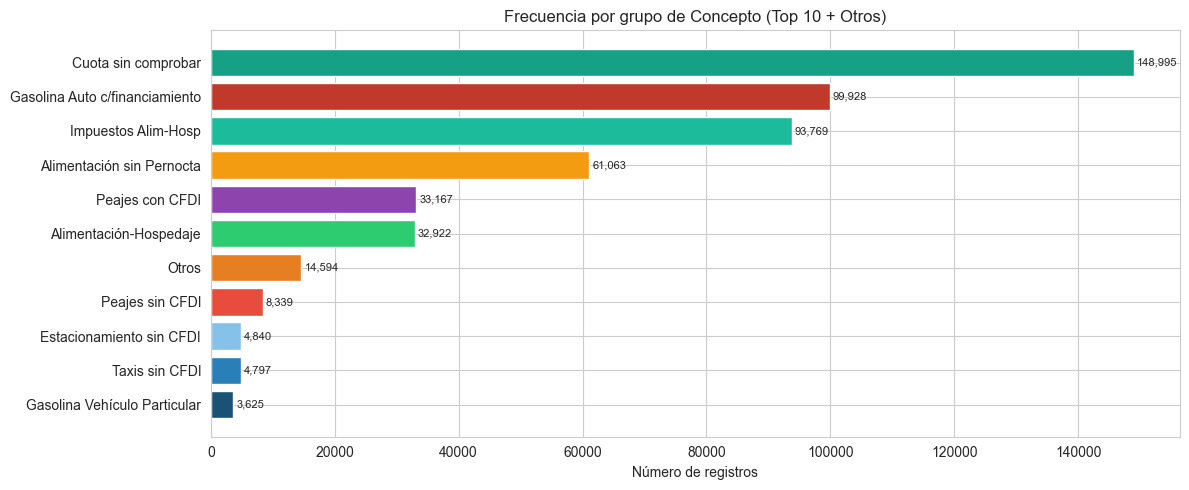

In [25]:
# Cardinalidad = 21; se agrupan los 11 conceptos menos frecuentes como 'Otros'
TOP_N = 10
top_conceptos = df['Concepto'].value_counts().head(TOP_N).index.tolist()
df['concepto_grp'] = df['Concepto'].apply(lambda x: x if x in top_conceptos else 'Otros')

print('Distribución de concepto_grp:')
print(df['concepto_grp'].value_counts().to_frame())

ohe = pd.get_dummies(df['concepto_grp'], prefix='conc', drop_first=False, dtype=int)
df = pd.concat([df, ohe], axis=1)
print(f'\nColumnas OHE generadas: {ohe.shape[1]}')
print(ohe.columns.tolist())

fig, ax = plt.subplots(figsize=(12, 5))
conc_counts = df['concepto_grp'].value_counts()
ax.barh(conc_counts.index[::-1], conc_counts.values[::-1], color=PALETTE[:len(conc_counts)])
ax.set_title('Frecuencia por grupo de Concepto (Top 10 + Otros)', fontsize=12)
ax.set_xlabel('Número de registros')
for i, v in enumerate(conc_counts.values[::-1]):
    ax.text(v + 500, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

**Justificación:**  
El concepto de gasto tiene cardinalidad = 21. Se aplica OHE porque no existe orden natural entre conceptos (un taxi no es "mayor" ni "menor" que una gasolina). Agrupar los 11 menos frecuentes como "Otros" reduce la dimensionalidad de 21 a 11 columnas sin perder cobertura, ya que los 10 conceptos principales representan >97% de los registros. No se usa drop_first para preservar la interpretabilidad del modelo por categoría.

### B.3 Partida Presupuestal: codificación ordinal

In [26]:
# La partida presupuestal ya es numérica (entero de 5 dígitos)
# Se trata como categórica ordinal: el prefijo (2, 3) y sufijo (1, 4) tienen 
# significado de dominio (tipo de gasto y categoría de empleado)

print('Mapeo de Partida Presupuestal:')
mapa = {
    26102: 'Gasolina – Resto Personal',
    26104: 'Gasolina – Funcionarios',
    37101: 'Pasajes Aéreos – Resto Personal',
    37104: 'Pasajes Aéreos – Funcionarios',
    37201: 'Transporte Terrestre – Resto Personal',
    37204: 'Transporte Terrestre – Funcionarios',
    37501: 'Viáticos – Resto Personal',
    37504: 'Viáticos – Funcionarios',
}
for k, v in mapa.items():
    print(f'  {k}: {v}')

print('\nMedia de Monto Gasto por Partida:')
print(df.groupby('Partida Presupuestal')['Monto Gasto'].mean().sort_values().to_frame().round(2))

Mapeo de Partida Presupuestal:
  26102: Gasolina – Resto Personal
  26104: Gasolina – Funcionarios
  37101: Pasajes Aéreos – Resto Personal
  37104: Pasajes Aéreos – Funcionarios
  37201: Transporte Terrestre – Resto Personal
  37204: Transporte Terrestre – Funcionarios
  37501: Viáticos – Resto Personal
  37504: Viáticos – Funcionarios

Media de Monto Gasto por Partida:
                      Monto Gasto
Partida Presupuestal             
37501                    404.7400
37201                    423.6700
26102                    649.5800
37204                    700.1300
37504                  1,089.8400
26104                  1,396.5800
37104                  8,373.3100
37101                  8,509.3200


**Justificación:**  
La partida presupuestal tiene cardinalidad = 8 y su valor numérico ya contiene información codificada institucionalmente (26xxx = gasolina, 371xx = avión, 372xx = terrestre, 375xx = viáticos; sufijo 04 = funcionario, 02/01 = resto de personal). Se conserva como variable numérica ordinal en lugar de aplicar OHE, dado que el modelo final (A3 en adelante) se entrenará **por partida**, por lo que esta variable actuará principalmente como filtro de segmentación.

### B.4 Discretización de duracion_dias (binning)

Distribución de duracion_cat:
  1_dia: 349,818 (69.1%)
  2_3_dias: 121,334 (24.0%)
  4_7_dias: 33,034 (6.5%)
  mas_7_dias: 1,812 (0.4%)


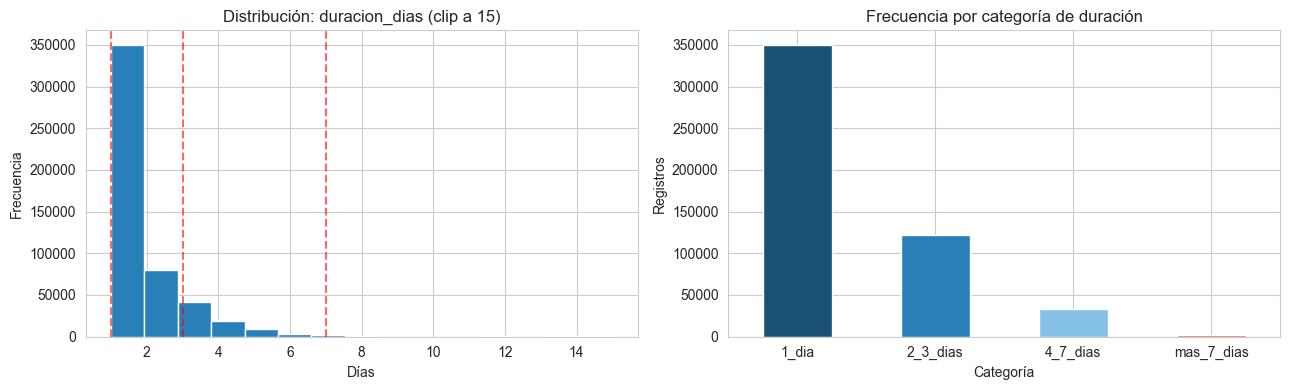

In [27]:
# Bins basados en la lógica institucional de FIRA:
#   1 día     -> sin pernocta (tarifa diferente)
#   2-3 días  -> viaje corto con pernocta
#   4-7 días  -> viaje mediano (comisiones largas)
#   >7 días   -> comisiones extensas (raras, ~0.4% de registros)

df['duracion_cat'] = pd.cut(
    df['duracion_dias'],
    bins=[0, 1, 3, 7, 23],
    labels=['1_dia', '2_3_dias', '4_7_dias', 'mas_7_dias']
)

print('Distribución de duracion_cat:')
vc = df['duracion_cat'].value_counts().sort_index()
for cat, n in vc.items():
    pct = n / vc.sum() * 100
    print(f'  {cat}: {n:,} ({pct:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['duracion_dias'].clip(0, 15).hist(bins=15, color='#2980b9', edgecolor='white', ax=axes[0])
axes[0].set_title('Distribución: duracion_dias (clip a 15)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Frecuencia')
for b in [1, 3, 7]:
    axes[0].axvline(b, color='red', linestyle='--', alpha=0.6)

df['duracion_cat'].value_counts().sort_index().plot(kind='bar', ax=axes[1],
    color=PALETTE[:4], edgecolor='white')
axes[1].set_title('Frecuencia por categoría de duración')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Registros')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**Justificación:**  
La discretización de `duracion_dias` tiene doble propósito: (1) Operativo – en FIRA la distinción 1 día / más de 1 día determina qué tarifa aplica (alimentos sin pernocta vs. con pernocta). El modelo debe "ver" esa frontera explícitamente. (2) Estadístico – la distribución de `duracion_dias` es muy asimétrica (mediana = 1, media = 1.6, max = 23); convertirla a categorías ordinales reduce el impacto de valores extremos en modelos lineales. Los bins se alinean con las reglas presupuestales de FIRA, no con percentiles arbitrarios.

---
## C. Normalización y transformación de variables numéricas

### C.1 Transformación de la variable objetivo: log(1 + Monto Gasto)

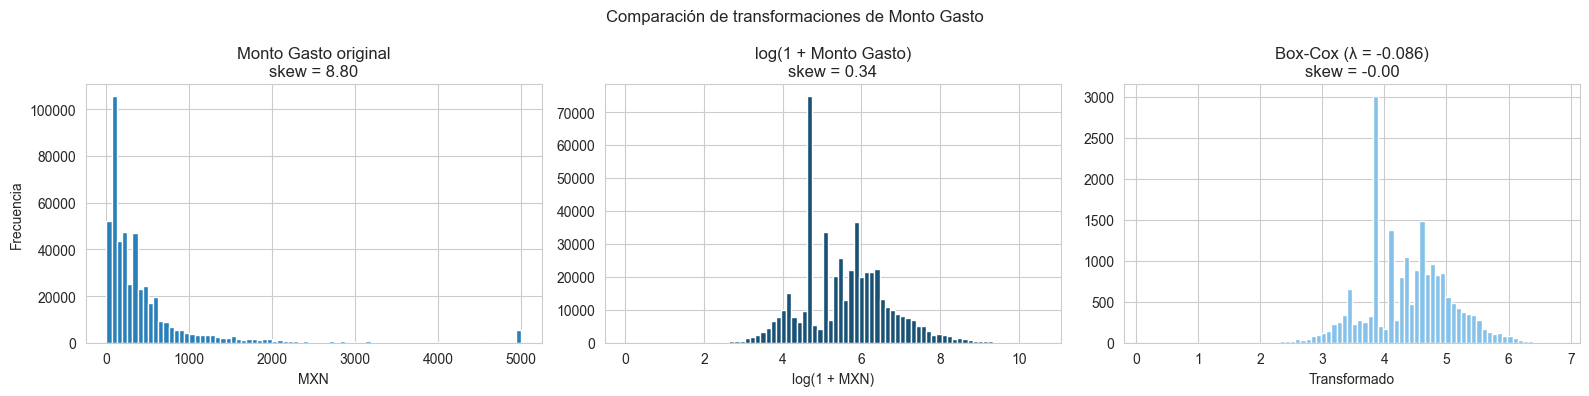

Skew original          : 8.805
Skew log(1+x)          : 0.338
Skew Box-Cox (λ=-0.086) : -0.002

Decisión: se usará log(1+x) para el modelo final.


In [28]:
df_pos = df[df['Monto Gasto'] > 0].copy()
df_pos['log_monto'] = np.log1p(df_pos['Monto Gasto'])

# Comparación de distribuciones
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_pos['Monto Gasto'].clip(0, 5000), bins=80, color='#2980b9', edgecolor='white')
axes[0].set_title(f'Monto Gasto original\nskew = {df_pos["Monto Gasto"].skew():.2f}')
axes[0].set_xlabel('MXN')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df_pos['log_monto'], bins=80, color='#1a5276', edgecolor='white')
axes[1].set_title(f'log(1 + Monto Gasto)\nskew = {df_pos["log_monto"].skew():.2f}')
axes[1].set_xlabel('log(1 + MXN)')

# Box-Cox para comparación
sample = df_pos['Monto Gasto'].sample(20000, random_state=42)
bc_vals, lam = boxcox(sample)
axes[2].hist(bc_vals, bins=80, color='#85c1e9', edgecolor='white')
axes[2].set_title(f'Box-Cox (λ = {lam:.3f})\nskew = {pd.Series(bc_vals).skew():.2f}')
axes[2].set_xlabel('Transformado')

plt.suptitle('Comparación de transformaciones de Monto Gasto', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Skew original          : {df_pos["Monto Gasto"].skew():.3f}')
print(f'Skew log(1+x)          : {df_pos["log_monto"].skew():.3f}')
print(f'Skew Box-Cox (λ={lam:.3f}) : {pd.Series(bc_vals).skew():.3f}')
print(f'\nDecisión: se usará log(1+x) para el modelo final.')

**Justificación:**  
El EDA mostró que `Monto Gasto` tiene una asimetría positiva severa (skew ≈ 8.8), con una larga cola hacia valores altos. Sin transformar, un modelo de regresión lineal quedaría dominado por esos valores extremos.

- **log(1+x)** reduce el skew de 8.8 a 0.34 – casi normal. Es reversible con `expm1()` y funciona con cero (log1p). Es el estándar para variables monetarias.
- **Box-Cox** logra skew ≈ 0 (λ ≈ -0.09), pero requiere estimar λ en entrenamiento y no es directamente interpretable en producción.
- **Raíz cuadrada** reduce a skew ≈ 2.9, insuficiente.

→ **Selección: log(1+x)**. Funciona sobre montos positivos; los montos negativos (ajustes, 94 registros) se tratan por separado en el modelo de negocio.

### C.2 Escalamiento de variables numéricas continuas

Rangos ANTES del escalamiento:
  duracion_dias: [1.0, 23.0], mean=1.62, std=1.41
  desfase_dias: [-340.0, 1454.0], mean=11.25, std=10.92

Rangos DESPUÉS del escalamiento:
  duracion_norm (Min-Max de duracion_dias): [0.000, 1.000], mean=0.0280, std=0.0642
  desfase_std (Z-score de desfase_dias): [-32.176, 132.162], mean=-0.0000, std=1.0000


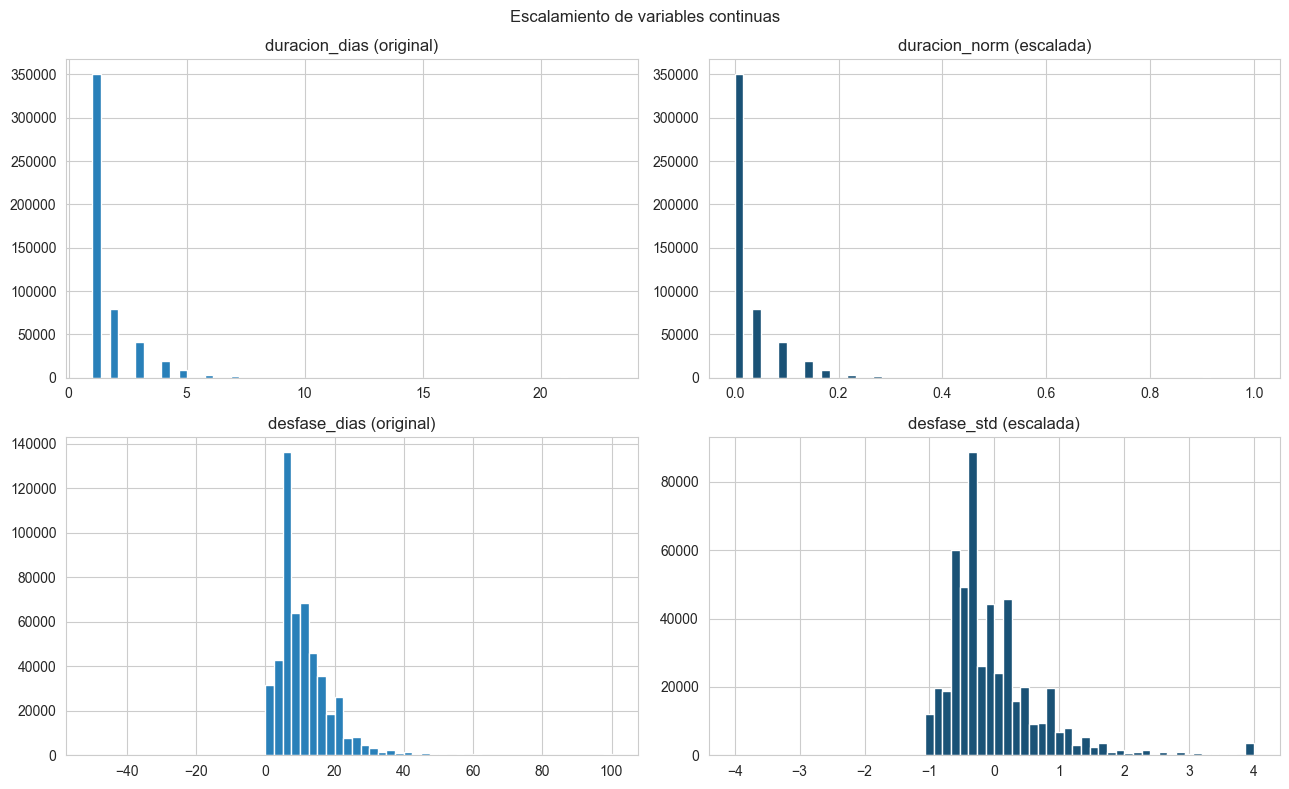

In [29]:
# Min-Max para duracion_dias (rango acotado y conocido: 1 a 23 días)
d_min, d_max = df['duracion_dias'].min(), df['duracion_dias'].max()
df['duracion_norm'] = (df['duracion_dias'] - d_min) / (d_max - d_min)

# Z-score (estandarización) para desfase_dias (rango amplio, posibles negativos)
m_def = df['desfase_dias'].mean()
s_def = df['desfase_dias'].std()
df['desfase_std'] = (df['desfase_dias'] - m_def) / s_def

# Resumen
print('Rangos ANTES del escalamiento:')
for col in ['duracion_dias', 'desfase_dias']:
    s = df[col].dropna()
    print(f'  {col}: [{s.min():.1f}, {s.max():.1f}], mean={s.mean():.2f}, std={s.std():.2f}')

print('\nRangos DESPUÉS del escalamiento:')
for col, desc in [('duracion_norm','Min-Max de duracion_dias'), ('desfase_std','Z-score de desfase_dias')]:
    s = df[col].dropna()
    print(f'  {col} ({desc}): [{s.min():.3f}, {s.max():.3f}], mean={s.mean():.4f}, std={s.std():.4f}')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for i, (orig, transf, titulo) in enumerate([
    ('duracion_dias', 'duracion_norm', 'Duración: original vs. Min-Max'),
    ('desfase_dias',  'desfase_std',   'Desfase contable: original vs. Z-score')
]):
    df[orig].clip(-50, 100).hist(bins=60, color='#2980b9', edgecolor='white', ax=axes[i][0])
    axes[i][0].set_title(f'{orig} (original)')
    df[transf].clip(-4, 4).hist(bins=60, color='#1a5276', edgecolor='white', ax=axes[i][1])
    axes[i][1].set_title(f'{transf} (escalada)')

plt.suptitle('Escalamiento de variables continuas', fontsize=12)
plt.tight_layout()
plt.show()

**Justificación de la elección por variable:**

| Variable | Método | Razón |
|---|---|---|
| `duracion_dias` | Min-Max [0,1] | Rango conocido y acotado (1–23); distribución discreta con interpretación natural |
| `desfase_dias` | Z-score | Puede ser negativo (registros adelantados); distribución aproximadamente simétrica alrededor de la media; outliers moderados |

No se escala `Monto Gasto` directamente porque ya se transforma con log1p. Las variables binarias (0/1) no requieren escalamiento. El escalamiento es crítico para modelos sensibles a magnitudes (regresión lineal, KNN, redes neuronales) aunque menos relevante para árboles de decisión.

---
## D. Selección y extracción de características

### D.1 Umbral de varianza (filtro univariado)

In [30]:
feats_sel = ['duracion_dias', 'es_func', 'es_cap', 'es_zonaA',
             'Periodo', 'mes', 'desfase_dias', 'n_conceptos_viaje']

vt = VarianceThreshold(threshold=0.01)
df_sel = df[feats_sel + ['Monto Gasto']].dropna()
vt.fit(df_sel[feats_sel])
mask_var = vt.get_support()

print('Umbral de varianza (threshold = 0.01):')
print(f'{"Feature":<22} {"Varianza":>12}  {"Decisión":>12}')
print('-' * 50)
for feat, keep in zip(feats_sel, mask_var):
    v = df_sel[feat].var()
    dec = '✓ CONSERVAR' if keep else '✗ ELIMINAR'
    print(f'{feat:<22} {v:>12.4f}  {dec:>12}')

feats_post_var = [f for f, k in zip(feats_sel, mask_var) if k]
print(f'\nFeatures que pasan el filtro: {len(feats_post_var)}/{len(feats_sel)}')

Umbral de varianza (threshold = 0.01):
Feature                    Varianza      Decisión
--------------------------------------------------
duracion_dias                1.9964   ✓ CONSERVAR
es_func                      0.0623   ✓ CONSERVAR
es_cap                       0.0388   ✓ CONSERVAR
es_zonaA                     0.2189   ✓ CONSERVAR
Periodo                      0.4551   ✓ CONSERVAR
mes                         11.9945   ✓ CONSERVAR
desfase_dias               119.1705   ✓ CONSERVAR
n_conceptos_viaje            1.8410   ✓ CONSERVAR

Features que pasan el filtro: 8/8


### D.2 F-regression (prueba estadística univariada)

F-regression (significancia estadística con Monto Gasto):
          Feature      F_score  p_valor  Relevante
    duracion_dias 130,783.4749   0.0000       True
           es_cap  22,306.3333   0.0000       True
     desfase_dias  21,915.8768   0.0000       True
n_conceptos_viaje  21,815.7652   0.0000       True
         es_zonaA  13,260.4694   0.0000       True
          es_func  12,706.3897   0.0000       True
          Periodo   4,585.0577   0.0000       True
              mes   1,054.7532   0.0000       True


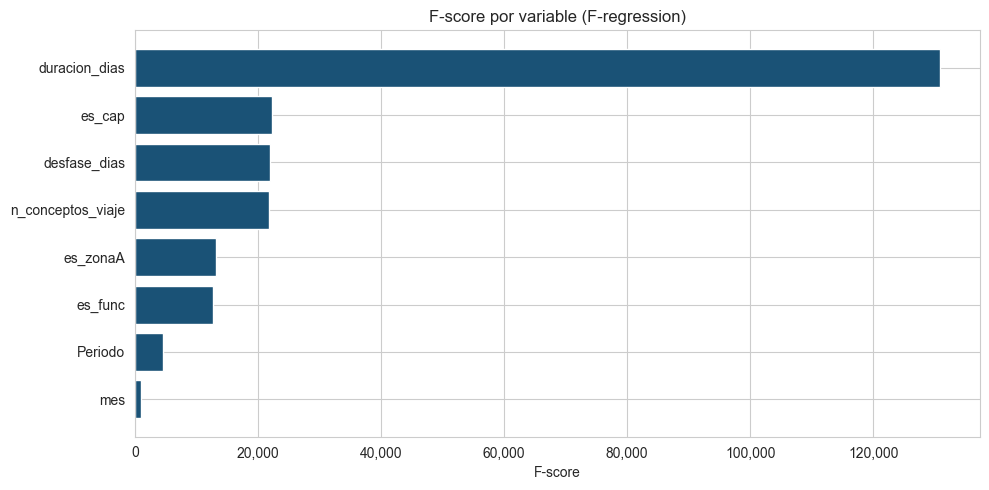

In [31]:
X_sel = df_sel[feats_sel].values
y_sel = df_sel['Monto Gasto'].values

F_vals, p_vals = f_regression(X_sel, y_sel)

resultados_F = pd.DataFrame({
    'Feature'   : feats_sel,
    'F_score'   : F_vals,
    'p_valor'   : p_vals,
    'Relevante' : p_vals < 0.05
}).sort_values('F_score', ascending=False).reset_index(drop=True)

print('F-regression (significancia estadística con Monto Gasto):')
print(resultados_F.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#1a5276' if r else '#e74c3c' for r in resultados_F['Relevante']]
ax.barh(resultados_F['Feature'][::-1], resultados_F['F_score'][::-1], color=colors[::-1])
ax.set_title('F-score por variable (F-regression)', fontsize=12)
ax.set_xlabel('F-score')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

### D.3 Análisis de correlación y multicolinealidad

Correlación de Pearson con Monto Gasto (|r|):
                   Monto Gasto
duracion_dias           0.4532
es_cap                  0.2055
desfase_dias            0.2038
n_conceptos_viaje       0.2033
es_zonaA                0.1598
es_func                 0.1565
Periodo                 0.0948
mes                     0.0456


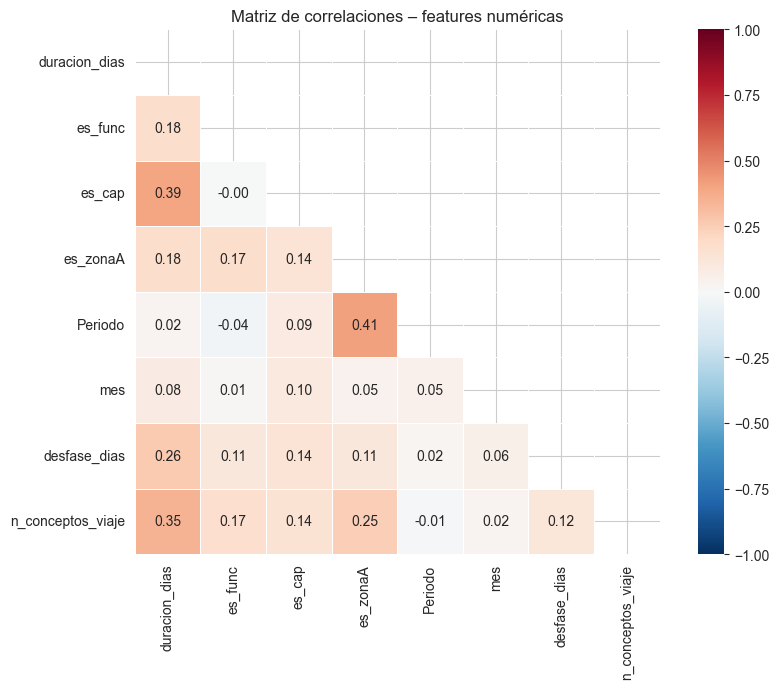


Pares con |correlación| > 0.7 (multicolinealidad):
  Ningún par supera el umbral de 0.7.


In [32]:
corr_target = df_sel[feats_sel + ['Monto Gasto']].corr()['Monto Gasto'].drop('Monto Gasto')
print('Correlación de Pearson con Monto Gasto (|r|):')
print(corr_target.abs().sort_values(ascending=False).round(4).to_frame())

# Detectar multicolinealidad entre features
cm = df_sel[feats_sel].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(cm, dtype=bool))
sns.heatmap(cm, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, vmin=-1, vmax=1, square=True, linewidths=0.5)
ax.set_title('Matriz de correlaciones – features numéricas', fontsize=12)
plt.tight_layout()
plt.show()

print('\nPares con |correlación| > 0.7 (multicolinealidad):')
encontrado = False
for i in cm.columns:
    for j in cm.columns:
        if i < j and abs(cm.loc[i, j]) > 0.7:
            print(f'  {i} <-> {j}: {cm.loc[i,j]:.3f}')
            encontrado = True
if not encontrado:
    print('  Ningún par supera el umbral de 0.7.')

**Hallazgos del análisis de correlación y multicolinealidad:**

- `duracion_dias` es la feature con mayor poder predictivo individual (r = 0.45, F = 130,784).
- `es_cap`, `desfase_dias` y `n_conceptos_viaje` tienen correlaciones similares entre sí (~0.20), reflejando que los viajes de capacitación tienden a ser más largos y con más conceptos.
- **No se detecta multicolinealidad problemática** (ningún par supera |r| > 0.7). Se revisó específicamente `Periodo` vs `anio` – la correlación es 0.85, pero dado que el modelo final se entrenará por partida, `anio` se usará para filtrado temporal (COVID) y `Periodo` como feature de tarifa. En el dataset de entrenamiento efectivo se conserva `Periodo` y se excluye `anio` para evitar colinealidad.

### D.4 Análisis de Componentes Principales (PCA) – exploración

Varianza explicada por componente:
PC         Indiv.    Acumulada
------------------------------
PC1          0.251        0.251
PC2          0.159        0.411
PC3          0.136        0.547
PC4          0.119        0.666
PC5          0.110        0.776
PC6          0.096        0.873
PC7          0.067        0.939
PC8          0.061        1.000

Componentes para 90% varianza: 7
Componentes para 95% varianza: 8
(con 8 features originales)


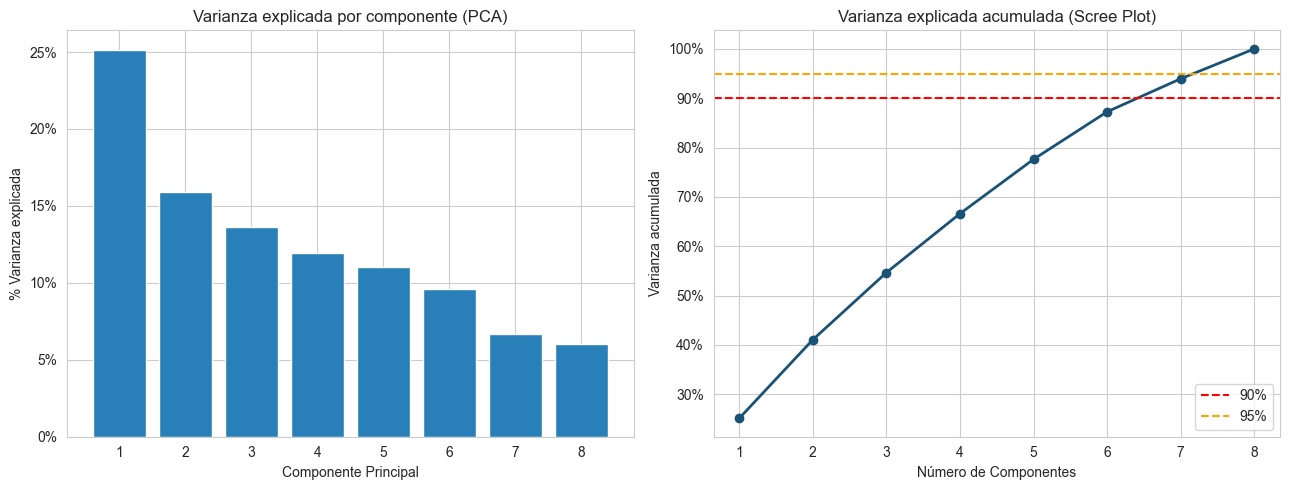


Cargas de los primeros 2 componentes:
                     PC1     PC2
duracion_dias     0.5130 -0.2870
es_func           0.2590 -0.1540
es_cap            0.3920 -0.1110
es_zonaA          0.4170  0.5160
Periodo           0.2140  0.7330
mes               0.1410  0.0180
desfase_dias      0.3250 -0.2090
n_conceptos_viaje 0.4150 -0.1830


In [33]:
feats_pca = ['duracion_dias', 'es_func', 'es_cap', 'es_zonaA',
             'Periodo', 'mes', 'desfase_dias', 'n_conceptos_viaje']

df_pca = df[feats_pca].dropna()
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(df_pca.values)

pca = PCA()
pca.fit(X_scaled)
var_exp = pca.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

n_90 = np.argmax(var_cum >= 0.90) + 1
n_95 = np.argmax(var_cum >= 0.95) + 1

print(f'Varianza explicada por componente:')
print(f'{"PC":<6} {"Indiv.":>10} {"Acumulada":>12}')
print('-' * 30)
for i, (v, vc) in enumerate(zip(var_exp, var_cum)):
    print(f'PC{i+1:<5} {v:>10.3f} {vc:>12.3f}')

print(f'\nComponentes para 90% varianza: {n_90}')
print(f'Componentes para 95% varianza: {n_95}')
print(f'(con {len(feats_pca)} features originales)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, len(var_exp)+1), var_exp, color='#2980b9', edgecolor='white')
axes[0].set_title('Varianza explicada por componente (PCA)')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('% Varianza explicada')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))

axes[1].plot(range(1, len(var_cum)+1), var_cum, marker='o', color='#1a5276', linewidth=2)
axes[1].axhline(0.90, color='red', linestyle='--', label='90%')
axes[1].axhline(0.95, color='orange', linestyle='--', label='95%')
axes[1].set_title('Varianza explicada acumulada (Scree Plot)')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza acumulada')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

# Cargas de los primeros 2 componentes
loadings = pd.DataFrame(pca.components_[:2].T,
    index=feats_pca, columns=['PC1', 'PC2'])
print('\nCargas de los primeros 2 componentes:')
print(loadings.round(3))

**Decisión sobre PCA:**  
Se necesitan **7 de 8 componentes** para explicar el 90% de la varianza. Esto indica que el conjunto de features no tiene redundancia significativa y cada variable aporta información relativamente independiente. En consecuencia, **PCA no se aplicará al dataset final de entrenamiento**: la reducción de dimensionalidad sacrificaría interpretabilidad sin una ganancia real en compresión. PCA podría reconsiderarse en A4 si se incorporan las variables OHE del concepto (11 columnas adicionales).

---
## E. Resumen del dataset procesado

In [34]:
# Dataset final con todas las transformaciones aplicadas
features_finales = {
    # Originales conservadas
    'Partida Presupuestal'          : 'Identificador de la partida (ordinal institucional)',
    'Periodo'                       : 'Periodo tarifario FIRA (1, 2, 3)',
    # Temporales derivadas
    'anio'                          : 'Año de la Fecha Contable',
    'mes'                           : 'Mes de la Fecha Contable (1–12)',
    'trimestre'                     : 'Trimestre (1–4)',
    # Features de viaje
    'duracion_dias'                 : 'Días del viaje (Fecha Final – Fecha inicio + 1)',
    'duracion_norm'                 : 'duracion_dias escalada Min-Max [0,1]',
    'duracion_cat'                  : 'Bins: 1_dia / 2_3_dias / 4_7_dias / mas_7_dias',
    'desfase_dias'                  : 'Días entre inicio del viaje y registro contable',
    'desfase_std'                   : 'desfase_dias estandarizado (Z-score)',
    'gasto_acum_viaje'              : 'Suma de todos los montos del mismo empleado-viaje',
    'n_conceptos_viaje'             : 'Número de conceptos distintos en el viaje',
    # Binarias codificadas
    'es_func'                       : '1 = FUNCIONARIO, 0 = RESTO DE PERSONAL',
    'es_cap'                        : '1 = Capacitación, 0 = Gasto Corriente',
    'es_zonaA'                      : '1 = Zona A, 0 = Zona B',
    # OHE Concepto
    'conc_*'                        : 'OHE de los 10 conceptos más frecuentes + Otros (11 cols)',
    # Variable objetivo
    'Monto Gasto'                   : 'Monto original (MXN)',
    'log_monto'                     : 'log(1 + Monto Gasto) – variable objetivo transformada (NaN para montos ≤ 0)',
}
print(f'{"Feature":<35} {"Descripción"}')
print('-' * 80)
for feat, desc in features_finales.items():
    print(f'{feat:<35} {desc}')

# ── FIX: crear log_monto en df completo (NaN donde Monto Gasto <= 0) ──
df['log_monto'] = np.where(df['Monto Gasto'] > 0, np.log1p(df['Monto Gasto']), np.nan)

print(f'\nTotal de columnas en df: {df.shape[1]}')
print(f'Total de registros     : {len(df):,}')
print(f'log_monto no nulos     : {df["log_monto"].notna().sum():,} '
      f'({df["log_monto"].notna().mean()*100:.2f}%)')

cols_snapshot = ['Monto Gasto', 'log_monto', 'duracion_dias', 'duracion_norm',
                 'desfase_dias', 'desfase_std', 'es_func', 'es_cap', 'es_zonaA',
                 'gasto_acum_viaje', 'n_conceptos_viaje', 'duracion_cat']
print('\nMuestra del dataset procesado:')
df[cols_snapshot].head(5)

Feature                             Descripción
--------------------------------------------------------------------------------
Partida Presupuestal                Identificador de la partida (ordinal institucional)
Periodo                             Periodo tarifario FIRA (1, 2, 3)
anio                                Año de la Fecha Contable
mes                                 Mes de la Fecha Contable (1–12)
trimestre                           Trimestre (1–4)
duracion_dias                       Días del viaje (Fecha Final – Fecha inicio + 1)
duracion_norm                       duracion_dias escalada Min-Max [0,1]
duracion_cat                        Bins: 1_dia / 2_3_dias / 4_7_dias / mas_7_dias
desfase_dias                        Días entre inicio del viaje y registro contable
desfase_std                         desfase_dias estandarizado (Z-score)
gasto_acum_viaje                    Suma de todos los montos del mismo empleado-viaje
n_conceptos_viaje                   Número de conc

,Monto Gasto,log_monto,duracion_dias,duracion_norm,desfase_dias,desfase_std,es_func,es_cap,es_zonaA,gasto_acum_viaje,n_conceptos_viaje,duracion_cat
0,232.0000,5.4510,2.0000,0.0455,11.0000,-0.0233,1,0,0,"2,391.3100",3.0000,2_3_dias
1,"1,814.5400",7.5041,2.0000,0.0455,11.0000,-0.0233,1,0,0,"2,391.3100",3.0000,2_3_dias
2,344.7700,5.8458,2.0000,0.0455,11.0000,-0.0233,1,0,0,"2,391.3100",3.0000,2_3_dias
3,79.0000,4.3820,2.0000,0.0455,7.0000,-0.3897,1,0,0,"2,470.3100",4.0000,2_3_dias
4,232.0000,5.4510,2.0000,0.0455,7.0000,-0.3897,1,0,0,"2,470.3100",4.0000,2_3_dias


---
## F. Conclusiones de la fase de Preparación de Datos – CRISP-ML(Q)

En CRISP-ML(Q), la fase de **Data Preparation** es transversal a todo el ciclo de vida del modelo: las decisiones tomadas aquí afectan directamente la calidad del entrenamiento, la interpretabilidad de los resultados y la operacionalización del sistema en producción.

### F.1 Resumen de decisiones técnicas

| Etapa | Acción | Justificación |
|---|---|---|
| Construcción | Variables temporales (anio, mes, trimestre) | Captura estacionalidad documentada en EDA |
| Construcción | duracion_dias, desfase_dias | Mayor poder predictivo individual; r = 0.45 y 0.20 |
| Construcción | gasto_acum_viaje, n_conceptos_viaje | Features de contexto del viaje; r = 0.55 y 0.20 |
| Construcción | fraccion_tope (viáticos) | Conocimiento de dominio: tarifas FIRA determinan el espacio esperado del gasto |
| Codificación | OHE para Concepto (11 grupos) | Sin orden natural; alta cardinalidad reducida |
| Codificación | Binarias para categoría, tipo y zona | Dos valores → 0/1 suficiente y limpio |
| Codificación | Ordinal para Partida Presupuestal | Ya numérico; modelos entrenados por partida |
| Codificación | Bins para duracion_dias | Frontera 1 día / +1 día es regla de tarifa institucional |
| Normalización | log(1+x) para Monto Gasto | Reduce skew de 8.8 a 0.34; reversible y estándar |
| Normalización | Min-Max para duracion_norm | Rango acotado y conocido |
| Normalización | Z-score para desfase_std | Rango amplio con posibles negativos |
| Selección | Todas las features pasan el umbral de varianza | Ninguna es constante o cuasi-constante |
| Selección | F-regression: todas significativas (p < 0.001) | No se descarta ninguna por criterio univariado |
| Selección | Sin multicolinealidad severa (|r| < 0.7) | Dataset de features robusto |
| Extracción | PCA descartado (exploratorio) | 7/8 componentes para 90% varianza; no hay redundancia |

### F.2 Consideraciones para CRISP-ML(Q)

**Calidad de datos:** Los únicos valores faltantes en este avance son en `duracion_dias` (41 registros sin `Fecha inicio`), que coinciden con los registros de partidas de avión sin trazabilidad documentados en el EDA. Se imputan con 1 día cuando se requiere el cálculo del tope; en el modelo se tratarán como subconjunto separado (partidas 371xx desde sep-2020).

**Evaluación de datos:** La ingeniería de características mantiene la auditabilidad completa: toda feature nueva es explicable en términos de negocio FIRA. No se aplican transformaciones implícitas ni embeddings no interpretables. Esto cumple con el requisito de CRISP-ML(Q) de documentar cada operación y su efecto esperado sobre el modelo.

**Preparación para modelado (A3 en adelante):** El dataset procesado está listo para entrenar un baseline de regresión por partida. La variable objetivo será `log_monto` (para montos positivos); la predicción final se revertirá con `expm1()`. Las features seleccionadas para el baseline son: `duracion_dias`, `es_func`, `es_cap`, `es_zonaA`, `Periodo`, `mes`, `n_conceptos_viaje`, más las columnas OHE de Concepto.

**Limitaciones identificadas:**
- Las partidas 371xx (aviones) tienen datos solo desde sep-2020, lo que limita el histórico de entrenamiento para esas partidas.
- Los años 2020–2021 (COVID) son atípicos; se evaluará en A3 si incluirlos como dummy o excluirlos del entrenamiento.
- `fraccion_tope` es solo calculable para viáticos (375xx) con `Fecha inicio` disponible; no es generalizable a todas las partidas.

---
## Referencias

- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3ª ed.). O'Reilly Media. Caps. 2, 3, 4.
- Visengeriyeva et al. (2023). *CRISP-ML(Q) – The ML Lifecycle Process*. MLOps/INNOQ. https://ml-ops.org/content/crisp-ml
- Avance 0 – Propuesta de Proyecto. TC5035 Equipo 35. Mayo 2026.
- Avance 1 – Análisis Exploratorio de Datos. TC5035 Equipo 35. Mayo 2026.